# 7. brain_1.3M_integration
**Author:** [Haihui Zhang](https://github.com/haihuilab/scbiot)
**Copyright:** [scbiot](https://scbiot.readthedocs.io/en/stable/)

This notebook was modified from [here] (https://rapids-singlecell.readthedocs.io/en/latest/notebooks/demo_gpu-seuratv3-brain-1M.html) with rapids-singlecell

## Setup
Import GPU/CPU dependencies and configure runtime settings.

In [1]:
import scanpy as sc
import anndata as ad
import cupy as cp
import numpy as np

import time
import os
from pathlib import Path
import rapids_singlecell as rsc

import scbiot as scb

import gc
import warnings

warnings.filterwarnings("ignore")

dir = Path(os.environ.get("SCBIOT_EXAMPLES_PATH", Path.cwd()))
print(dir)

sc.logging.print_header()

/home/figo/software/python_libs/scbiot/.venv/lib/python3.12/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/home/figo/software/python_libs/scbiot/.venv/lib/python3.12/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/home/figo/software/python_libs/scbiot/.venv/lib/python3.12/site-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/home/figo/software/python_libs/scbiot/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .au

scbiot version 1.1.8
/home/figo/software/python_libs/scbiot/examples


Package,Version
scanpy,1.11.4
anndata,0.12.6
cupy-cuda12x,13.6.0
numpy,1.26.4
rapids_singlecell,0.13.5
scbiot,1.1.8
Component,Info
Python,"3.12.8 (main, Jan 14 2025, 22:49:14) [Clang 19.1.6 ]"
OS,Linux-6.11.0-29-generic-x86_64-with-glibc2.39
CPU,"64 logical CPU cores, x86_64"


## Load and Prepare Data

We load the sparse count matrix from an `h5ad` file using Scanpy. The sparse count matrix will then be placed on the GPU. 

In [2]:
data_load_start = time.time()

In [3]:
h5_path = f"{dir}/inputs/1M_neurons_filtered_gene_bc_matrices_h5.h5"

adata = sc.read_10x_h5(
    h5_path,
    backup_url='https://s3-us-west-2.amazonaws.com/10x.files/samples/cell/1M_neurons/1M_neurons_filtered_gene_bc_matrices_h5.h5',
)
adata.var_names_make_unique()

### Configure parameters
Set marker genes, QC thresholds, and embedding parameters.

In [4]:
# marker genes
MITO_GENE_PREFIX = "mt-" # Prefix for mitochondrial genes to regress out
markers = ["Stmn2", "Hes1", "Olig1"] # Marker genes for visualization

# filtering cells
min_genes_per_cell = 200 # Filter out cells with fewer genes than this expressed 
max_genes_per_cell = 6000 # Filter out cells with more genes than this expressed 

# filtering genes
min_cells_per_gene = 1 # Filter out genes expressed in fewer cells than this
n_top_genes = 4000 # Number of highly variable genes to retain

# PCA
n_components = 100 # Number of principal components to compute

# KNN
n_neighbors = 15 # Number of nearest neighbors for KNN graph
knn_n_pcs = 50 # Number of principal components to use for finding nearest neighbors

# UMAP
umap_min_dist = 0.3 
umap_spread = 1.0

# Gene ranking
ranking_n_top_genes = 50 # Number of differential genes to compute for each cluster

In [5]:
start = time.time()

Verify the shape of the resulting sparse matrix:

In [6]:
adata.shape

(1306127, 27998)

## Preprocessing

In [7]:
preprocess_start = time.time()

### Create batch labels

In [8]:
# Parse suffix after the last '-'
suffix = adata.obs_names.str.rsplit('-', n=1).str[1]

# Store as categorical to save memory
adata.obs["batch"] = suffix.astype("category")

adata.obs["batch"].head()

AAACCTGAGATAGGAG-1    1
AAACCTGAGCGGCTTC-1    1
AAACCTGAGGAATCGC-1    1
AAACCTGAGGACACCA-1    1
AAACCTGAGGCCCGTT-1    1
Name: batch, dtype: category
Categories (133, object): ['1', '10', '100', '101', ..., '96', '97', '98', '99']

### Quality Control

We perform a basic qulitiy control and plot the results

In [9]:
%%time
sc.pp.filter_cells(adata, min_genes=min_genes_per_cell)
sc.pp.filter_cells(adata, max_genes=max_genes_per_cell)

CPU times: user 31.6 s, sys: 13.9 s, total: 45.5 s
Wall time: 45.5 s


In [10]:
%%time
sc.pp.filter_genes(adata, min_cells=min_cells_per_gene)

CPU times: user 16.6 s, sys: 4.82 s, total: 21.4 s
Wall time: 21.4 s


In [11]:
%%time
mito_genes = adata.var_names.str.startswith(MITO_GENE_PREFIX)
n_counts = np.array(adata.X.sum(axis=1))
adata.obs['percent_mito'] = np.array(np.sum(adata[:, mito_genes].X, axis=1)) / n_counts
adata.obs['n_counts'] = n_counts

CPU times: user 3.44 s, sys: 68 μs, total: 3.44 s
Wall time: 3.44 s


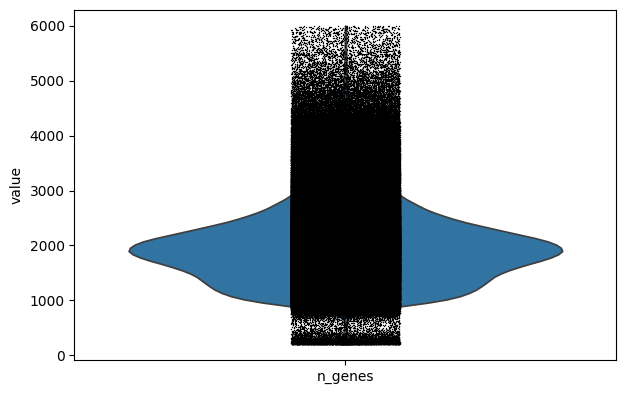

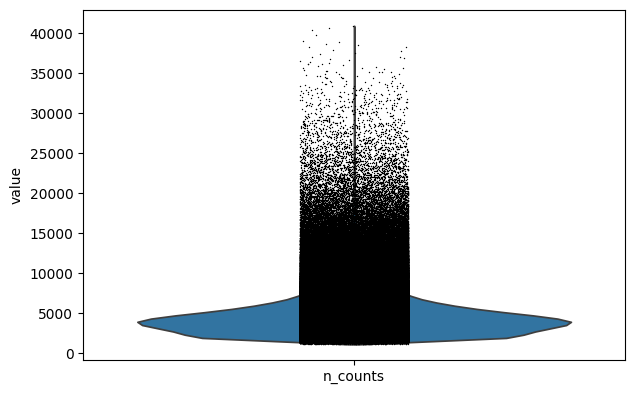

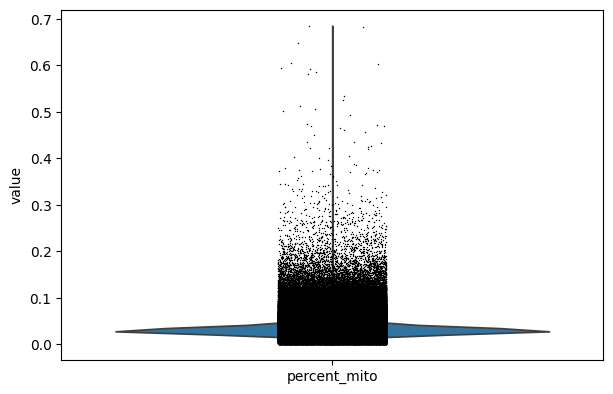

CPU times: user 20.4 s, sys: 9.03 s, total: 29.4 s
Wall time: 9.75 s


In [12]:
%%time
sc.pl.violin(adata, keys="n_genes")
sc.pl.violin(adata, keys="n_counts")
sc.pl.violin(adata, keys="percent_mito")

### Normalize, Scale, and select Most Variable Genes

In [13]:
%%time
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=n_top_genes, flavor = "cell_ranger")

# Retain marker gene expression
for marker in markers:
    adata.obs[marker + "_raw"] = adata.X[:, adata.var.index == marker].toarray().ravel()

# Filter matrix to only variable genes
adata = adata[:, adata.var.highly_variable]

CPU times: user 37.4 s, sys: 1.21 s, total: 38.6 s
Wall time: 12.4 s


In [14]:
%%time
gc.collect()

CPU times: user 168 ms, sys: 343 μs, total: 168 ms
Wall time: 167 ms


3051

### Regress out confounding factors (number of counts, mitochondrial gene expression)

In [15]:
%%time
sc.pp.regress_out(adata, ['n_counts', 'percent_mito'])

CPU times: user 48.9 s, sys: 2min 31s, total: 3min 20s
Wall time: 11.9 s


In [16]:
adata.shape

(1291337, 4000)

### Scale

In [17]:
%%time
sc.pp.scale(adata, max_value=10)

CPU times: user 31.4 s, sys: 895 ms, total: 32.3 s
Wall time: 12.9 s


### Principal component analysis

We use PCA to reduce the dimensionality of the matrix to its top 100 principal components. 

In [18]:
%%time
sc.tl.pca(adata, n_comps=n_components)

CPU times: user 1h 54min 54s, sys: 17min 20s, total: 2h 12min 15s
Wall time: 2min 48s


We can use scanpy `pca_variance_ratio` plot to inspect the contribution of single PCs to the total variance in the data.

In [19]:
# sc.pl.pca_variance_ratio(adata, log=True, n_pcs=100)

### Run OT

In [20]:
adata, metrics = scb.ot.integrate(adata, 
                                  obsm_key='X_pca', 
                                  batch_key='batch', 
                                  out_key='X_ot')
print(metrics)

[baseline] KNN backend=FAISS-GPU mix=3.1373 strain=0.00000
[iter 01] mix=3.192 overlap0=0.853 strain=0.00045 floor~0.600 J=0.158 best_it=1
[iter 02] mix=3.201 overlap0=0.786 strain=0.00090 floor~0.607 J=0.190 best_it=2
[iter 03] mix=3.204 overlap0=0.740 strain=0.00315 floor~0.614 J=0.191 best_it=3
[iter 04] mix=3.207 overlap0=0.695 strain=0.01273 floor~0.621 J=0.176 best_it=3
[iter 05] mix=3.207 overlap0=0.694 strain=0.01251 floor~0.629 J=0.175 best_it=3
[iter 06] mix=3.207 overlap0=0.703 strain=0.01279 floor~0.636 J=0.181 best_it=3
[early stop] plateau reached.
[final] it*=3 mix=3.204 overlap0=0.740 strain=0.00315 tw=0.997
[label transfer] skipped; pass label_key to compute alignment metadata
{'mix': 3.20428763122602, 'overlap0': 0.7401466965675354, 'strain': 0.0031453301415237415, 'tw': 0.9965960806681605, 'it': 3}


## Export
Save the OT embedding to disk for reuse.

In [21]:
adata.write(f"{dir}/inputs/brain_1M.h5ad", compression="lzf")


In [2]:
adata = sc.read(f"{dir}/inputs/brain_1M.h5ad")

In [3]:
X_ot = np.asarray(adata.obsm["X_ot"], dtype="float32")  # (1291337, 100)

# 2) Build a new AnnData with PCs as X
adata_ot = ad.AnnData(
    X=X_ot,
    obs=adata.obs.copy(),   # keep all metadata (batch, cell_type, etc.)
)

# Give the PCs names, optional but nice
adata_ot.var_names = [f"OT{i+1}" for i in range(X_ot.shape[1])]

adata_ot.obsm["X_ot"] = X_ot


We now load the the AnnData object into VRAM.

### Calculate pseudo labels for tracking model performance. Here we begin to use GPU to speed it up

In [4]:
import rmm
from rmm.allocators.cupy import rmm_cupy_allocator

rmm.reinitialize(
    managed_memory=False,  # Allows oversubscription
    pool_allocator=False,  # default is False
    devices=0,  # GPU device IDs to register. By default registers only GPU 0.
)
cp.cuda.set_allocator(rmm_cupy_allocator)

In [5]:
%%time
rsc.get.anndata_to_GPU(adata_ot)

CPU times: user 30.3 ms, sys: 206 ms, total: 236 ms
Wall time: 234 ms


In [6]:
# 1. Compute neighbors using Harmony-corrected PCA
rsc.pp.neighbors(adata_ot, use_rep='X_ot')

# 2. Run UMAP 
rsc.tl.umap(adata_ot)

# 3. Leiden clustering
rsc.tl.leiden(adata_ot, resolution=0.8, key_added='leiden_X_ot')
adata_ot

AnnData object with n_obs × n_vars = 1291337 × 100
    obs: 'batch', 'n_genes', 'percent_mito', 'n_counts', 'Stmn2_raw', 'Hes1_raw', 'Olig1_raw', 'leiden_X_ot'
    uns: 'neighbors', 'umap', 'leiden_X_ot'
    obsm: 'X_ot', 'X_umap'
    obsp: 'distances', 'connectivities'

## Visualize
Plot UMAP for the OT embedding to inspect clustering structure.

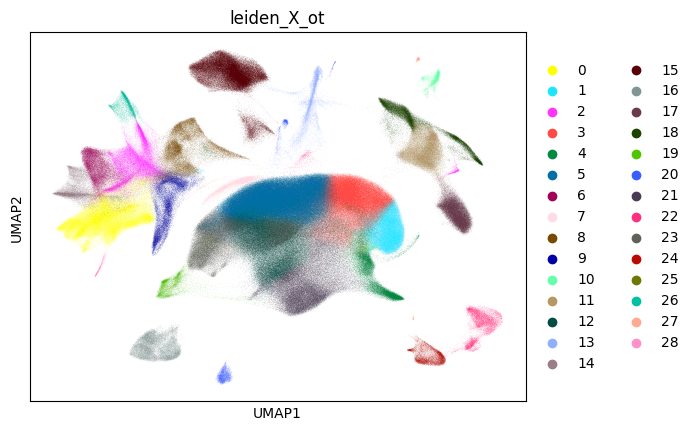

CPU times: user 3.06 s, sys: 169 ms, total: 3.22 s
Wall time: 3.05 s


In [8]:
%%time
sc.pl.umap(
    adata_ot,
    color=['leiden_X_ot'],
    ncols=1
)